In [2]:
import pandas as pd

In [3]:
file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")
file.shape

C:\Users\Sahil\AppData\Local\Temp\ipykernel_26264\3336156477.py:1: DtypeWarning: Columns (5: Gallery Number, 7: AccessionYear, 10: Culture, 11: Period, 12: Dynasty, 13: Reign, 14: Portfolio, 34: Geography Type, 35: City, 36: State, 37: County, 38: Country, 39: Region, 40: Subregion, 41: Locale, 42: Locus, 43: Excavation, 44: River, 45: Classification, 46: Rights and Reproduction) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")


(484956, 54)

In [4]:
file.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979.0,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980.0,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [5]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  str    
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  str    
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  str    
 9   Title                    456153 non-null  str    
 10  Culture                  208190 non-null  str    
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   str    
 13  Reign                    11236 non-null   str    
 14  Portfolio      

In [8]:
to_keep = file.loc[(file["Department"].isin(["Asian Art", "European Paintings"])) & (file["Is Public Domain"] == True)]
to_keep.shape

(33622, 54)

In [10]:
cols_to_keep = ["Object ID", "Title", "Artist Display Name", "Object Date", "Medium", "Culture", "Credit Line", "Department"]

candidate_df = to_keep[cols_to_keep]
candidate_df.head()

,Object ID,Title,Artist Display Name,Object Date,Medium,Culture,Credit Line,Department
30295,35966,NaN,NaN,18th–19th century,Leather,Japan,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30296,35967,NaN,NaN,18th century or earlier,Paint; on leather,China,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30297,35968,清 佚名 台南地區荷蘭城堡|Forts Zeelandia and Provintia ...,Unidentified artist,19th century,Wall hanging; ink and color on deerskin,China,"Gift of J. Pierpont Morgan, 1909",Asian Art
30299,35970,明 丁雲鵬 潯陽送客圖 軸|Song of the Lute,Ding Yunpeng,1585,Hanging scroll; ink and color on paper,China,"John Stewart Kennedy Fund, 1913",Asian Art
30300,35971,清 佚名 倣王翬 倣李成山水圖 軸|Landscape after Li C...,Wang Hui|Unidentified artist,"18th century or later, spurious date of 1680",Hanging scroll; ink on silk,China,"John Stewart Kennedy Fund, 1913",Asian Art


In [11]:
candidate_df["Culture"].unique()

<StringArray>
[                                          'Japan',
                                           'China',
                                           'Korea',
                                     'North China',
 'China (Xinjiang Autonomous Region, Turfan area)',
                                  'China or Japan',
                               'India, Tamil Nadu',
                                        'Thailand',
           'Pakistan (ancient region of Gandhara)',
                                           'India',
 ...
               'North Central Thailand, Sukhothai',
                      'Vietnam, Hong River region',
                       'Myanmar (Burma), Mandalay',
                          'South India, Karnataka',
                  'Kashmir style in Western Tibet',
                      'India, Madurai, Tamil Nadu',
              'India, Kolkata (formerly Calcutta)',
           'South India, Andhra Pradesh, Tirupati',
                           'Eastern India, Od

In [14]:
candidate_df.to_csv("../data/processed/candidates.csv", index=False)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.dossier import build_dossier, UnusableRecordError

candidates = pd.read_csv("../data/processed/candidates.csv")
sample_ids = candidates["Object ID"].head(5).tolist()

for oid in sample_ids:
    try:
        print(build_dossier(oid))
    except UnusableRecordError as e:
        print(f"Skipped: {e}")

object_id=35966 title='Piece' artist=None date='18th–19th century' medium='Leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11408.jpg' is_public_domain=True
object_id=35967 title='Panel' artist=None date='18th century or earlier' medium='Paint; on leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11577.jpg' is_public_domain=True
object_id=35968 title='Forts Zeelandia and Provintia and the City of Tainan' artist='Unidentified artist' date='19th century' medium='Wall hanging; ink and color on deerskin' department='Asian Art' credit_line='Gift of J. Pierpont Morgan, 1909' image_url='https://images.metmuseum.org/CRDImages/as/original/DP354272.jpg' is_public_domain=True
object_id=35970 title='Song of the Lute' artist='Ding Yunpeng' date='1585' medium='Hanging scroll; ink and color on pap

In [2]:
from src.agents import supervisor

for oid in sample_ids:
    dossier = build_dossier(oid)
    result = supervisor(dossier)
    print(oid, result.flag, result.reason)

35966 False No contradiction found by any specialist.
35967 False No contradiction found by any specialist.
35968 False No contradiction found by any specialist.
35970 False No contradiction found by any specialist.
35971 True [date] The record states '18th century or later' and also mentions a 'spurious date of 1680', which creates a conflict as 1680 is in the 17th century.


In [3]:
import sys
sys.path.append("..")

from dotenv import load_dotenv
load_dotenv()

from src.workflow import dossier_graph

import logging
logging.getLogger("langsmith").setLevel(logging.WARNING)


for oid in sample_ids:
    result = dossier_graph.invoke({"object_id": oid, "raw_data": None, "error": None, "dossier": None})
    a = result["assessment"]
    print(oid, a.flag, a.confidence, "-", a.reason)

Object 35966: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'Leather'}, 'id': 'call_GMbMG8aCvwxAJAp6tiROCENn', 'type': 'tool_call'}]
Object 35966: reason = 'No contradiction was found.'
Object 35966: routing -> clean
35966 False High - No contradiction was found.
Object 35967: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'leather'}, 'id': 'call_2FKGwoqxhZLAVsQ4n4SofL1K', 'type': 'tool_call'}, {'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'paint'}, 'id': 'call_JF5xqNeob707xjZSbWKNIx5w', 'type': 'tool_call'}]
Object 35967: reason = 'No contradiction was found.'
Object 35967: routing -> clean
35967 False high - No contradiction was found.
Object 35968: tool_calls = [{'name': 'check_medium_frequency', 'args': {'department': 'Asian Art', 'medium_keyword': 'deerskin'}, 'id': 'call_jE5ogyrlUCAYmkBuPWedGp86', 'type': 'tool_call'}]
Object 

In [1]:
import sys
sys.path.append("..")

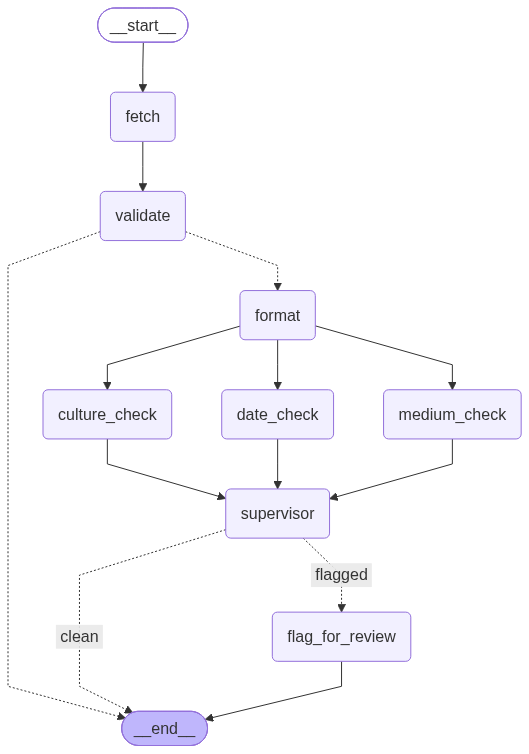

In [ ]:
from dotenv import load_dotenv

import sys
sys.path.append("..")
load_dotenv()

from src.workflow import dossier_graph

from multiagent_workflow import multi_agent_graph

multi_agent_graph

In [3]:
from src.multiagent_workflow import multi_agent_graph

sample_ids = [35966, 35967, 35968, 35970, 35971]

for oid in sample_ids:
    result = multi_agent_graph.invoke({
        "object_id": oid,
        "raw_data": None,
        "error": None,
        "dossier": None,
        "date_verdict": None,
        "culture_verdict": None,
        "medium_verdict": None,
        "assessment": None,
    })
    print(oid, result["assessment"].flag, result["assessment"].reason)


35966 False No contradiction found by any specialist.
35967 False No contradiction found by any specialist.
35968 False No contradiction found by any specialist.
35970 False No contradiction found by any specialist.
35971 True [date] The record states '18th century or later' and also mentions a 'spurious date of 1680', which creates a conflict between the two dates.


In [3]:
dossier_clean = build_dossier(35966)
print(date_specialist(dossier_clean))

date_conflict=False reason="The date is given as '18th–19th century', which is a broad range and does not conflict with itself."


In [5]:
print(medium_specialist(build_dossier(35971)))   # expect medium_anachronism=False (its issue was the date, not the medium)
print(medium_specialist(build_dossier(35966)))   # expect medium_anachronism=False (leather, but common enough)

medium_anachronism=False reason="The medium 'ink on silk' is not anachronistic for the 18th century, as it was commonly used in Asian art. Additionally, silk as a medium is not rare in the Asian Art department, with 6795 instances recorded."
medium_anachronism=False reason='Leather as a medium was commonly used during the 18th–19th century and is not rare in the Asian Art department.'


In [5]:
from src.agents import *
from src.dossier import build_dossier

dossier = build_dossier(35971)
flag_reason = "The record states '18th century or later' and also mentions a 'spurious date of 1680', which creates a conflict."
print(correction_specialist(dossier, flag_reason))

NameError: name 'correction_specialist' is not defined